### Ordinary differential equation

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
import sympy as sp

#### Part c

In [5]:
# Define the symbolic variables
r, a, b, c, k = sp.symbols('r a b c k')

# Define the matrix J
J = sp.Matrix([
    [-1 * r * b / c / k, -1 * a * b / c],
    [r * c / a - r * b / a / k, 0]
])

# Calculate eigenvalues
eigenvalues = J.eigenvals()

print(J)
print("Symbolic eigenvalues:", eigenvalues)


Matrix([[-b*r/(c*k), -a*b/c], [-b*r/(a*k) + c*r/a, 0]])
Symbolic eigenvalues: {-b*r/(2*c*k) - sqrt(b*r*(4*b*c*k + b*r - 4*c**2*k**2))/(2*c*k): 1, -b*r/(2*c*k) + sqrt(b*r*(4*b*c*k + b*r - 4*c**2*k**2))/(2*c*k): 1}


### part d

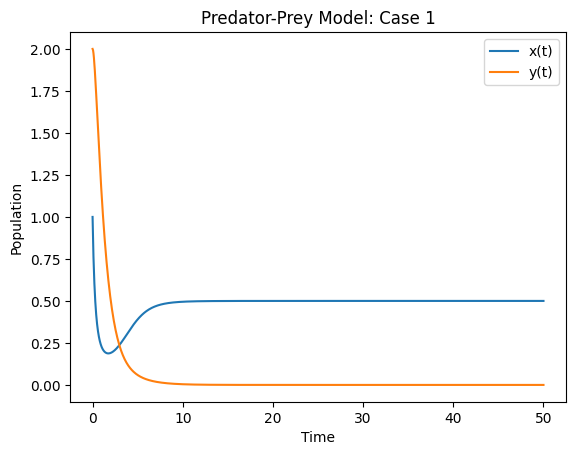

Execution time for Case 1: 0.012521028518676758 seconds


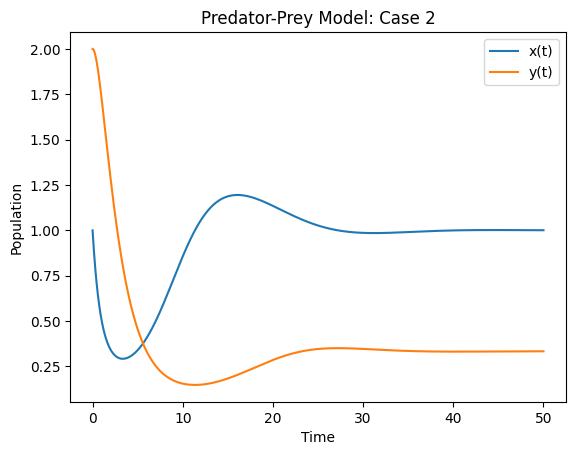

Execution time for Case 2: 0.009708166122436523 seconds


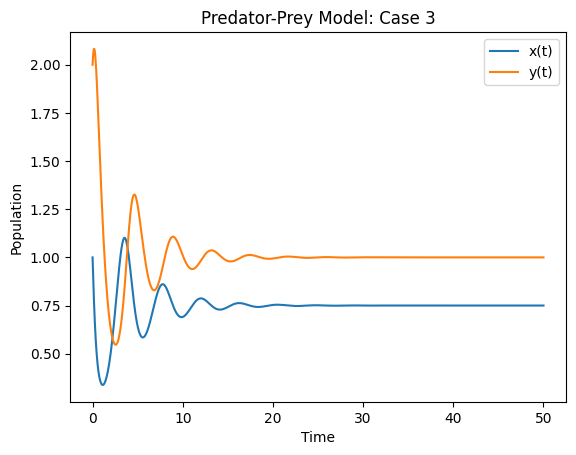

Execution time for Case 3: 0.02039813995361328 seconds


In [6]:
def my_function(t, y, r, K, a, b, c):
    dxdt = y[0] * (r - r * y[0] / K - a * y[1])
    dydt = y[1] * (-b + c * y[0])
    return [dxdt, dydt]

# Define parameter sets for three cases
parameter_sets = [
    {"r": 1.0, "K": 0.5, "a": 1, "b": 1, "c": 1},
    {"r": 0.5, "K": 1.5, "a": 0.5, "b": 0.5, "c": 0.5},
    {"r": 2.0, "K": 3.0, "a": 1.5, "b": 1.5, "c": 2.0}
]

# Tolerances
rtol = 1e-6  # Relative tolerance
atol = 1e-8  # Absolute tolerance

# Loop through each parameter set
for idx, params in enumerate(parameter_sets):
    # Initial conditions
    t_initial = 0.0
    y_initial = np.array([1.0, 2.0])  # Initial values of x and y

    # Time span
    t_span = (t_initial, 50.0)  # Integration time from t_initial to 50.0

    # Measure the execution time
    start_time = time.time()

    # Integrate using RK45 method with specified tolerances
    solution = solve_ivp(lambda t, y: my_function(t, y, **params), t_span, y_initial, method='RK45', t_eval=np.linspace(t_initial, t_span[1], 1000), rtol=rtol, atol=atol)

    # Calculate execution time
    execution_time = time.time() - start_time

    # Access the results
    t_values = solution.t
    x_values = solution.y[0]
    y_values = solution.y[1]

    # Plot the results
    plt.figure(idx + 1)
    plt.plot(t_values, x_values, label='x(t)')
    plt.plot(t_values, y_values, label='y(t)')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title(f'Predator-Prey Model: Case {idx + 1}')
    plt.legend()
    plt.show()

    print(f"Execution time for Case {idx + 1}:", execution_time, "seconds")
